# Real-time Network Intrusion Detection System (IDS)
## Thành viên B - Quản lý dữ liệu và EDA
### Mục 2.1: Source Code Management | Mục 2.2: EDA và Preprocessing

**Dataset:** CIC-IDS2017 - Canadian Institute for Cybersecurity

**Nội dung thực hiện trong notebook:**
- Thiết lập cấu trúc Git/GitHub cho project.
- Load và gộp 8 file CSV thành một DataFrame.
- Làm sạch dữ liệu: tên cột, NaN, Inf, duplicate và cột không có phương sai.
- Tối ưu kiểu dữ liệu để giảm RAM.
- Khám phá dữ liệu: phân phối nhãn, tương quan feature và boxplot.
- Xuất dữ liệu đã xử lý để chuyển sang bước huấn luyện mô hình.

---
## 2.1 Source Code Management với Git và GitHub

### Thiết lập repository

Các lệnh dưới đây chạy trong **Terminal / Command Prompt**, không chạy trực tiếp trong notebook.

```bash
# Bước 1: Tạo repository mới trên GitHub
# GitHub -> New Repository -> đặt tên Network-Intrusion-Detection-ML
# Chọn Public, thêm README.md và .gitignore Python

# Bước 2: Clone repository về máy
git clone https://github.com/<your-username>/Network-Intrusion-Detection-ML.git
cd Network-Intrusion-Detection-ML

# Bước 3: Mời thành viên C và D
# Settings -> Collaborators -> Add people

# Bước 4: Tạo cấu trúc thư mục
mkdir -p data/raw data/processed models notebooks reports

# Bước 5: Commit cấu trúc ban đầu
git add .
git commit -m "init: project structure setup"
git push origin main
```

### Cấu trúc thư mục dự án

```
Network-Intrusion-Detection-ML/
├-- data/
│   ├-- raw/          # 8 file CSV gốc từ CIC-IDS2017
│   └-- processed/    # dữ liệu sau khi xử lý
├-- models/           # file mô hình .pkl
├-- notebooks/
│   ├-- B_EDA_Preprocessing.ipynb
│   ├-- C_Model_Training.ipynb
│   └-- D_Realtime_Alert.ipynb
└-- reports/          # hình ảnh EDA và kết quả báo cáo
```

---
## 2.2 Exploratory Data Analysis (EDA) & Data Preprocessing

### Bước 0: Cài đặt thư viện

In [1]:
# Cài đặt thư viện cần thiết. Chỉ cần chạy một lần nếu môi trường chưa có đủ package.
import subprocess

packages = [
    'pandas', 'numpy', 'matplotlib', 'seaborn',
    'scikit-learn', 'imbalanced-learn', 'joblib'
]

for pkg in packages:
    subprocess.run(['pip', 'install', pkg, '-q'], check=True)

print('Cài đặt thư viện hoàn tất.')

Cài đặt thư viện hoàn tất.


### Bước 1: Import thư viện

In [2]:
# Import thư viện
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

# Cấu hình hiển thị cơ bản
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
sns.set_theme(style='whitegrid', palette='muted')

print('Import thư viện thành công.')
print(f'pandas: {pd.__version__}')
print(f'numpy : {np.__version__}')

Import thư viện thành công.
pandas: 3.0.2
numpy : 2.4.4


### Bước 2: Merge Data - Load 8 file CSV thành 1 DataFrame

> **Hướng dẫn tải dataset:**  
> Truy cập: https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset  
> Tải về và giải nén vào thư mục `data/raw/`  
> 8 file CSV bao gồm: Monday, Tuesday, Wednesday, Thursday-Morning, Thursday-Afternoon, Friday-DoS, Friday-PortScan, Friday-DDoS

In [3]:
# Cấu hình đường dẫn
DATA_RAW_DIR = Path('../data/raw')
DATA_PROC_DIR = Path('../data/processed')
REPORT_DIR = Path('../reports')
DATA_PROC_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Danh sách 8 file CSV theo bộ CIC-IDS2017
CSV_FILES = [
    'Monday-WorkingHours.pcap_ISCX.csv',
    'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday-workingHours.pcap_ISCX.csv',
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
]

print('Bắt đầu load và gộp các file CSV...')
print('-' * 50)

dfs = []
missing_files = []
for fname in CSV_FILES:
    fpath = DATA_RAW_DIR / fname
    if fpath.exists():
        df_tmp = pd.read_csv(fpath, low_memory=False, encoding='utf-8', on_bad_lines='skip')
        dfs.append(df_tmp)
        print(f'{fname:<60} {len(df_tmp):>10,} rows')
    else:
        missing_files.append(fname)
        print(f'Không tìm thấy file: {fname}')

if missing_files:
    raise FileNotFoundError(
        f'Chua du 8 file CSV. Thieu {len(missing_files)} file: {missing_files}. '
        f'Vui long dat du du lieu vao thu muc: {DATA_RAW_DIR.resolve()}'
    )

if not dfs:
    raise FileNotFoundError(
        'Không tìm thấy file CSV nào. '
        f'Vui lòng đặt 8 file CSV vào thư mục: {DATA_RAW_DIR.resolve()}'
    )

# Gộp tất cả file thành một DataFrame
df = pd.concat(dfs, ignore_index=True)

print('-' * 50)
print('Tổng quan sau khi merge:')
print(f'Số dòng : {len(df):>12,}')
print(f'Số cột  : {df.shape[1]:>12,}')
print(f'RAM     : {df.memory_usage(deep=True).sum() / 1024**2:>11.1f} MB')

Bắt đầu load và gộp các file CSV...
--------------------------------------------------
Monday-WorkingHours.pcap_ISCX.csv                               529,918 rows
Tuesday-WorkingHours.pcap_ISCX.csv                              445,909 rows
Wednesday-workingHours.pcap_ISCX.csv                            692,703 rows
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv          170,366 rows
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv     288,602 rows
Friday-WorkingHours-Morning.pcap_ISCX.csv                       191,033 rows
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv            286,467 rows
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv                225,745 rows
--------------------------------------------------
Tổng quan sau khi merge:
Số dòng :    2,830,743
Số cột  :           79
RAM     :      1723.1 MB


### Bước 3: Kiểm tra tổng quan dữ liệu thô

In [4]:
# Xem 5 dòng đầu của dataset
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,...,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,3000000.0000,...,0,0,329,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,12000000.0000,...,0,0,329,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,12000000.0000,...,0,0,329,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,12000000.0000,...,0,0,329,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,4000000.0000,...,0,0,245,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN


In [5]:
# Kiểm tra kiểu dữ liệu và số lượng giá trị non-null
print(df.info(show_counts=True))

<class 'pandas.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0    Destination Port             2830743 non-null  int64  
 1    Flow Duration                2830743 non-null  int64  
 2    Total Fwd Packets            2830743 non-null  int64  
 3    Total Backward Packets       2830743 non-null  int64  
 4   Total Length of Fwd Packets   2830743 non-null  int64  
 5    Total Length of Bwd Packets  2830743 non-null  int64  
 6    Fwd Packet Length Max        2830743 non-null  int64  
 7    Fwd Packet Length Min        2830743 non-null  int64  
 8    Fwd Packet Length Mean       2830743 non-null  float64
 9    Fwd Packet Length Std        2830743 non-null  float64
 10  Bwd Packet Length Max         2830743 non-null  int64  
 11   Bwd Packet Length Min        2830743 non-null  int64  
 12   Bwd Packet Length Mean       2830743 n

In [6]:
# Thống kê mô tả cho 10 cột đầu tiên
df.describe().iloc[:, :10]

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std
count,2830743.0000,2830743.0000,2830743.0000,2830743.0000,2830743.0000,2830743.0000,2830743.0000,2830743.0000,2830743.0000,2830743.0000
mean,8071.4825,14785663.9295,9.3612,10.3938,549.3024,16162.6425,207.5999,18.7137,58.2019,68.9101
std,18283.6322,33653744.0859,749.6728,997.3883,9993.5892,2263088.0517,717.1848,60.3393,186.0912,281.1871
min,0.0000,-13.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,53.0000,155.0000,2.0000,1.0000,12.0000,0.0000,6.0000,0.0000,6.0000,0.0000
50%,80.0000,31316.0000,2.0000,2.0000,62.0000,123.0000,37.0000,2.0000,34.0000,0.0000
75%,443.0000,3204828.5000,5.0000,4.0000,187.0000,482.0000,81.0000,36.0000,50.0000,26.1630
max,65535.0000,119999998.0000,219759.0000,291922.0000,12900000.0000,655453030.0000,24820.0000,2325.0000,5940.8571,7125.5968


In [7]:
# Phân phối nhãn ban đầu trước khi làm sạch
print('Phân phối nhãn trên dữ liệu thô:')
print('-' * 50)

# Xử lý sơ bộ khoảng trắng trong tên cột để đọc được Label
df.columns = df.columns.str.strip()

label_col = 'Label'
label_counts_raw = df[label_col].value_counts()

for label, count in label_counts_raw.items():
    pct = count / len(df) * 100
    print(f'{label:<40}: {count:>10,} ({pct:>5.1f}%)')

print()
print(f'Tổng số mẫu: {len(df):,}')
print(f'Số loại traffic: {label_counts_raw.nunique()}')

Phân phối nhãn trên dữ liệu thô:
--------------------------------------------------
BENIGN                                  :  2,273,097 ( 80.3%)
DoS Hulk                                :    231,073 (  8.2%)
PortScan                                :    158,930 (  5.6%)
DDoS                                    :    128,027 (  4.5%)
DoS GoldenEye                           :     10,293 (  0.4%)
FTP-Patator                             :      7,938 (  0.3%)
SSH-Patator                             :      5,897 (  0.2%)
DoS slowloris                           :      5,796 (  0.2%)
DoS Slowhttptest                        :      5,499 (  0.2%)
Bot                                     :      1,966 (  0.1%)
Web Attack � Brute Force                :      1,507 (  0.1%)
Web Attack � XSS                        :        652 (  0.0%)
Infiltration                            :         36 (  0.0%)
Web Attack � Sql Injection              :         21 (  0.0%)
Heartbleed                              :       

### Bước 4: Data Cleaning - Làm sạch dữ liệu

In [8]:
# 4.1 Xóa khoảng trắng thừa trong tên cột
print('Bước 4.1: Xử lý tên cột')

before_cols = df.columns.tolist()
df.columns = df.columns.str.strip()
after_cols = df.columns.tolist()

fixed = [(b, a) for b, a in zip(before_cols, after_cols) if b != a]
if fixed:
    print(f'Đã sửa {len(fixed)} tên cột có khoảng trắng:')
    for old, new in fixed[:5]:
        print(f'  "{old}" -> "{new}"')
else:
    print('Tên cột đã đúng định dạng.')

assert 'Label' in df.columns, 'Không tìm thấy cột Label sau khi xử lý tên cột.'
print(f'Cột Label có {df["Label"].nunique()} nhãn khác nhau.')

Bước 4.1: Xử lý tên cột
Tên cột đã đúng định dạng.
Cột Label có 15 nhãn khác nhau.


In [9]:
# 4.2 Xử lý giá trị Infinite và NaN
print('Bước 4.2: Xử lý Inf và NaN')

numeric_cols = df.select_dtypes(include=[np.number]).columns

n_inf_before = np.isinf(df[numeric_cols]).sum().sum()
n_nan_before = df.isna().sum().sum()
print('Trước khi xử lý:')
print(f'  Inf: {n_inf_before:>10,}')
print(f'  NaN: {n_nan_before:>10,}')

# Đưa Inf về NaN, sau đó thay NaN bằng median của từng cột số
df.replace([np.inf, -np.inf], np.nan, inplace=True)
medians = df[numeric_cols].median()
df[numeric_cols] = df[numeric_cols].fillna(medians)

n_inf_after = np.isinf(df[numeric_cols]).sum().sum()
n_nan_after = df.isna().sum().sum()
print()
print('Sau khi xử lý:')
print(f'  Inf: {n_inf_after:>10,}')
print(f'  NaN: {n_nan_after:>10,}')

Bước 4.2: Xử lý Inf và NaN
Trước khi xử lý:
  Inf:      4,376
  NaN:      1,358

Sau khi xử lý:
  Inf:          0
  NaN:          0


In [10]:
# 4.3 Xóa các feature có phương sai bằng 0
print('Bước 4.3: Xóa zero-variance features')

n_cols_before = df.shape[1]

numeric_cols_upd = df.select_dtypes(include=[np.number]).columns
zero_var_cols = numeric_cols_upd[df[numeric_cols_upd].var() == 0].tolist()

if zero_var_cols:
    df.drop(columns=zero_var_cols, inplace=True)
    print(f'Đã xóa {len(zero_var_cols)} cột zero-variance:')
    for c in zero_var_cols:
        print(f'  - {c}')
else:
    print('Không có cột zero-variance.')

print(f'Số cột: {n_cols_before} -> {df.shape[1]}')

Bước 4.3: Xóa zero-variance features
Đã xóa 8 cột zero-variance:
  - Bwd PSH Flags
  - Bwd URG Flags
  - Fwd Avg Bytes/Bulk
  - Fwd Avg Packets/Bulk
  - Fwd Avg Bulk Rate
  - Bwd Avg Bytes/Bulk
  - Bwd Avg Packets/Bulk
  - Bwd Avg Bulk Rate
Số cột: 79 -> 71


In [11]:
# 4.4 Xóa dòng trùng lặp
print('Bước 4.4: Xóa dòng trùng lặp')

n_rows_before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
n_rows_after = len(df)
n_removed = n_rows_before - n_rows_after

print(f'Số dòng trước: {n_rows_before:>12,}')
print(f'Số dòng xóa  : {n_removed:>12,} ({n_removed / n_rows_before * 100:.2f}%)')
print(f'Số dòng sau  : {n_rows_after:>12,}')

Bước 4.4: Xóa dòng trùng lặp
Số dòng trước:    2,830,743
Số dòng xóa  :      308,381 (10.89%)
Số dòng sau  :    2,522,362


### Bước 5: Memory Optimization - Tối ưu bộ nhớ

In [12]:
# Downcast dtype để giảm RAM sử dụng
print('Bước 5: Tối ưu kiểu dữ liệu')
print('-' * 50)

mem_before = df.memory_usage(deep=True).sum() / 1024**2

def optimize_dtypes(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Giảm kích thước kiểu int và float khi không làm mất miền giá trị."""
    df_opt = dataframe.copy()
    
    for col in df_opt.select_dtypes(include=['int64', 'int32']).columns:
        col_min, col_max = df_opt[col].min(), df_opt[col].max()
        if col_min >= 0:
            if col_max <= np.iinfo(np.uint8).max:
                df_opt[col] = df_opt[col].astype(np.uint8)
            elif col_max <= np.iinfo(np.uint16).max:
                df_opt[col] = df_opt[col].astype(np.uint16)
            elif col_max <= np.iinfo(np.uint32).max:
                df_opt[col] = df_opt[col].astype(np.uint32)
        else:
            if col_min >= np.iinfo(np.int8).min and col_max <= np.iinfo(np.int8).max:
                df_opt[col] = df_opt[col].astype(np.int8)
            elif col_min >= np.iinfo(np.int16).min and col_max <= np.iinfo(np.int16).max:
                df_opt[col] = df_opt[col].astype(np.int16)
            elif col_min >= np.iinfo(np.int32).min and col_max <= np.iinfo(np.int32).max:
                df_opt[col] = df_opt[col].astype(np.int32)
    
    for col in df_opt.select_dtypes(include=['float64']).columns:
        df_opt[col] = df_opt[col].astype(np.float32)
    
    return df_opt

df = optimize_dtypes(df)

mem_after = df.memory_usage(deep=True).sum() / 1024**2
reduction = (1 - mem_after / mem_before) * 100

print(f'RAM trước tối ưu : {mem_before:>8.1f} MB')
print(f'RAM sau tối ưu   : {mem_after:>8.1f} MB')
print(f'Mức giảm         : {reduction:>8.1f}%')
print()
print('Kiểu dữ liệu sau khi downcast:')
for dtype, count in df.dtypes.value_counts().items():
    print(f'  {str(dtype):<12}: {count} cột')

Bước 5: Tối ưu kiểu dữ liệu
--------------------------------------------------
RAM trước tối ưu :   1381.6 MB
RAM sau tối ưu   :    614.2 MB
Mức giảm         :     55.5%

Kiểu dữ liệu sau khi downcast:
  float32     : 24 cột
  uint32      : 18 cột
  uint8       : 11 cột
  int32       : 8 cột
  uint16      : 7 cột
  int64       : 2 cột
  str         : 1 cột


### Bước 6: EDA - Khám phá dữ liệu

#### 6.1 Phân phối các loại tấn công

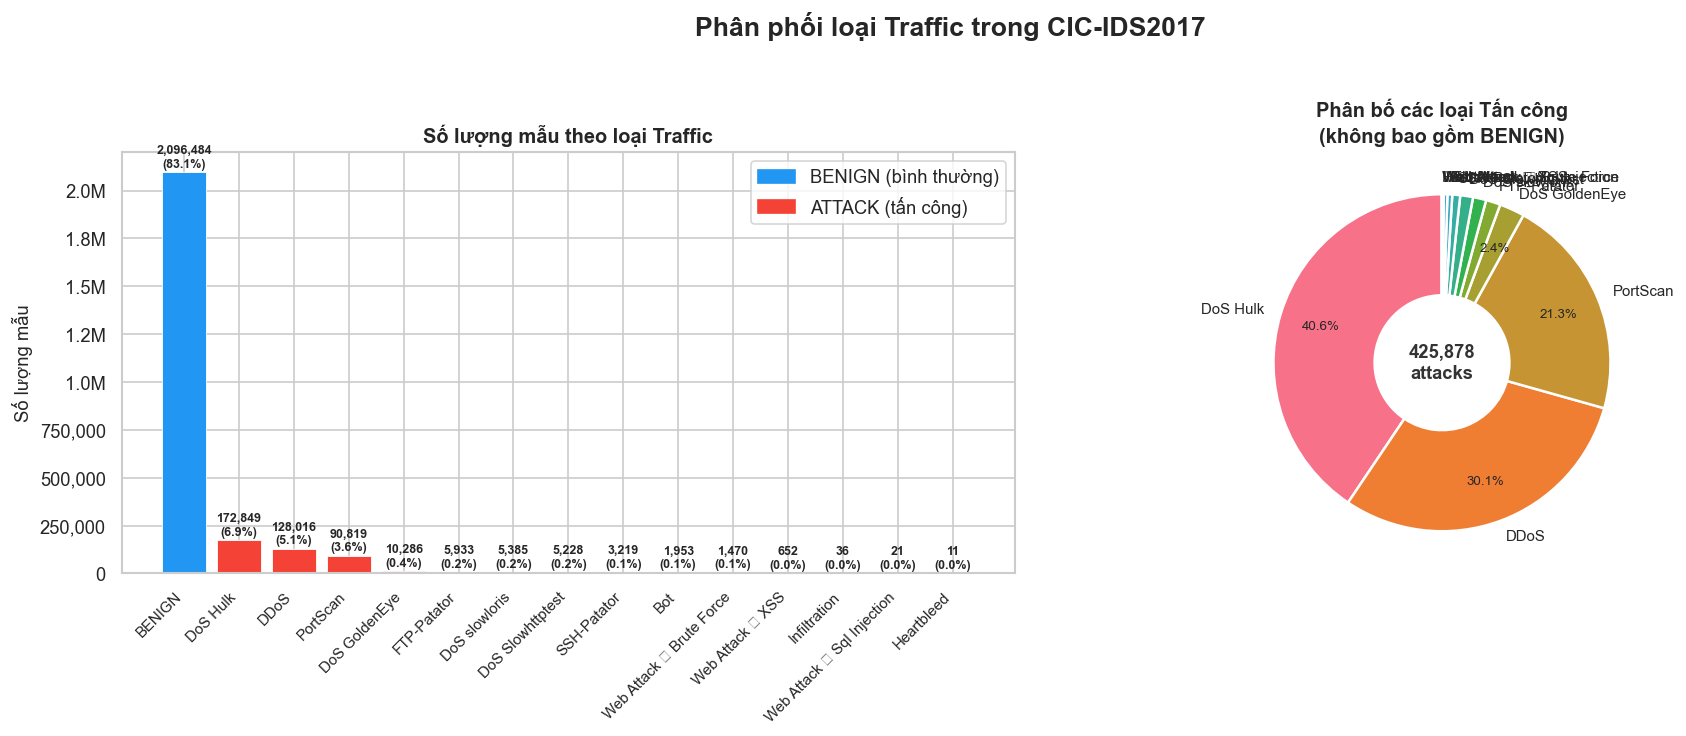

Đã lưu biểu đồ tại reports/eda_label_distribution.png


In [13]:
# Plot 1: Phân phối nhãn (Label Distribution)
label_counts = df['Label'].value_counts()
total = len(df)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Phân phối loại Traffic trong CIC-IDS2017', fontsize=16, fontweight='bold', y=1.02)

# -- Subplot 1: Bar chart (tất cả nhãn) ----------------------------------------
ax1 = axes[0]
colors = ['#2196F3' if l == 'BENIGN' else '#F44336' for l in label_counts.index]
bars = ax1.bar(range(len(label_counts)), label_counts.values, color=colors, edgecolor='white', linewidth=0.5)

# Thêm số liệu lên mỗi bar
for i, (bar, count) in enumerate(zip(bars, label_counts.values)):
    pct = count / total * 100
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.005,
             f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax1.set_xticks(range(len(label_counts)))
ax1.set_xticklabels(label_counts.index, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Số lượng mẫu', fontsize=11)
ax1.set_title('Số lượng mẫu theo loại Traffic', fontsize=12, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x:,.0f}'))

# Legend
from matplotlib.patches import Patch
ax1.legend(handles=[Patch(color='#2196F3', label='BENIGN (bình thường)'),
                     Patch(color='#F44336', label='ATTACK (tấn công)')], loc='upper right')

# -- Subplot 2: Pie chart (chỉ attack types, loại trừ BENIGN) ------------------
ax2 = axes[1]
attack_counts = label_counts[label_counts.index != 'BENIGN']

wedge_props = dict(width=0.6, edgecolor='white', linewidth=1.5)  # Donut chart
palette = sns.color_palette('husl', len(attack_counts))
wedges, texts, autotexts = ax2.pie(
    attack_counts.values,
    labels=attack_counts.index,
    autopct=lambda pct: f'{pct:.1f}%' if pct > 2 else '',
    colors=palette,
    wedgeprops=wedge_props,
    startangle=90,
    pctdistance=0.75,
)
for text in texts:   text.set_fontsize(9)
for atext in autotexts: atext.set_fontsize(8)
ax2.text(0, 0, f'{attack_counts.sum():,}\nattacks', ha='center', va='center',
         fontsize=11, fontweight='bold', color='#333333')
ax2.set_title('Phân bố các loại Tấn công\n(không bao gồm BENIGN)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/eda_label_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('Đã lưu biểu đồ tại reports/eda_label_distribution.png')

In [14]:
# Bảng tóm tắt phân phối nhãn
print()
print('Bảng tóm tắt phân phối nhãn:')
print('-' * 60)
print(f'{"Loại Traffic":<40} {"Số mẫu":>10} {"Tỷ lệ":>8}')
print('-' * 60)

for label, count in label_counts.items():
    pct = count / total * 100
    print(f'{label:<40} {count:>10,} {pct:>7.2f}%')

print('-' * 60)
print(f'{"TỔNG":<40} {total:>10,} {100.0:>7.1f}%')

benign_pct = label_counts.get('BENIGN', 0) / total * 100
print()
print('Nhận xét về mất cân bằng lớp:')
print(f'BENIGN chiếm {benign_pct:.1f}% dataset, dữ liệu bị mất cân bằng rõ.')
print('Phần huấn luyện mô hình có thể xử lý bằng SMOTE và RandomUnderSampler.')


Bảng tóm tắt phân phối nhãn:
------------------------------------------------------------
Loại Traffic                                 Số mẫu    Tỷ lệ
------------------------------------------------------------
BENIGN                                    2,096,484   83.12%
DoS Hulk                                    172,849    6.85%
DDoS                                        128,016    5.08%
PortScan                                     90,819    3.60%
DoS GoldenEye                                10,286    0.41%
FTP-Patator                                   5,933    0.24%
DoS slowloris                                 5,385    0.21%
DoS Slowhttptest                              5,228    0.21%
SSH-Patator                                   3,219    0.13%
Bot                                           1,953    0.08%
Web Attack � Brute Force                      1,470    0.06%
Web Attack � XSS                                652    0.03%
Infiltration                                     36    

#### 6.2 Correlation Heatmap - Ma trận tương quan

Kiểm tra 18 selected features:
   Có trong data   : 18/18


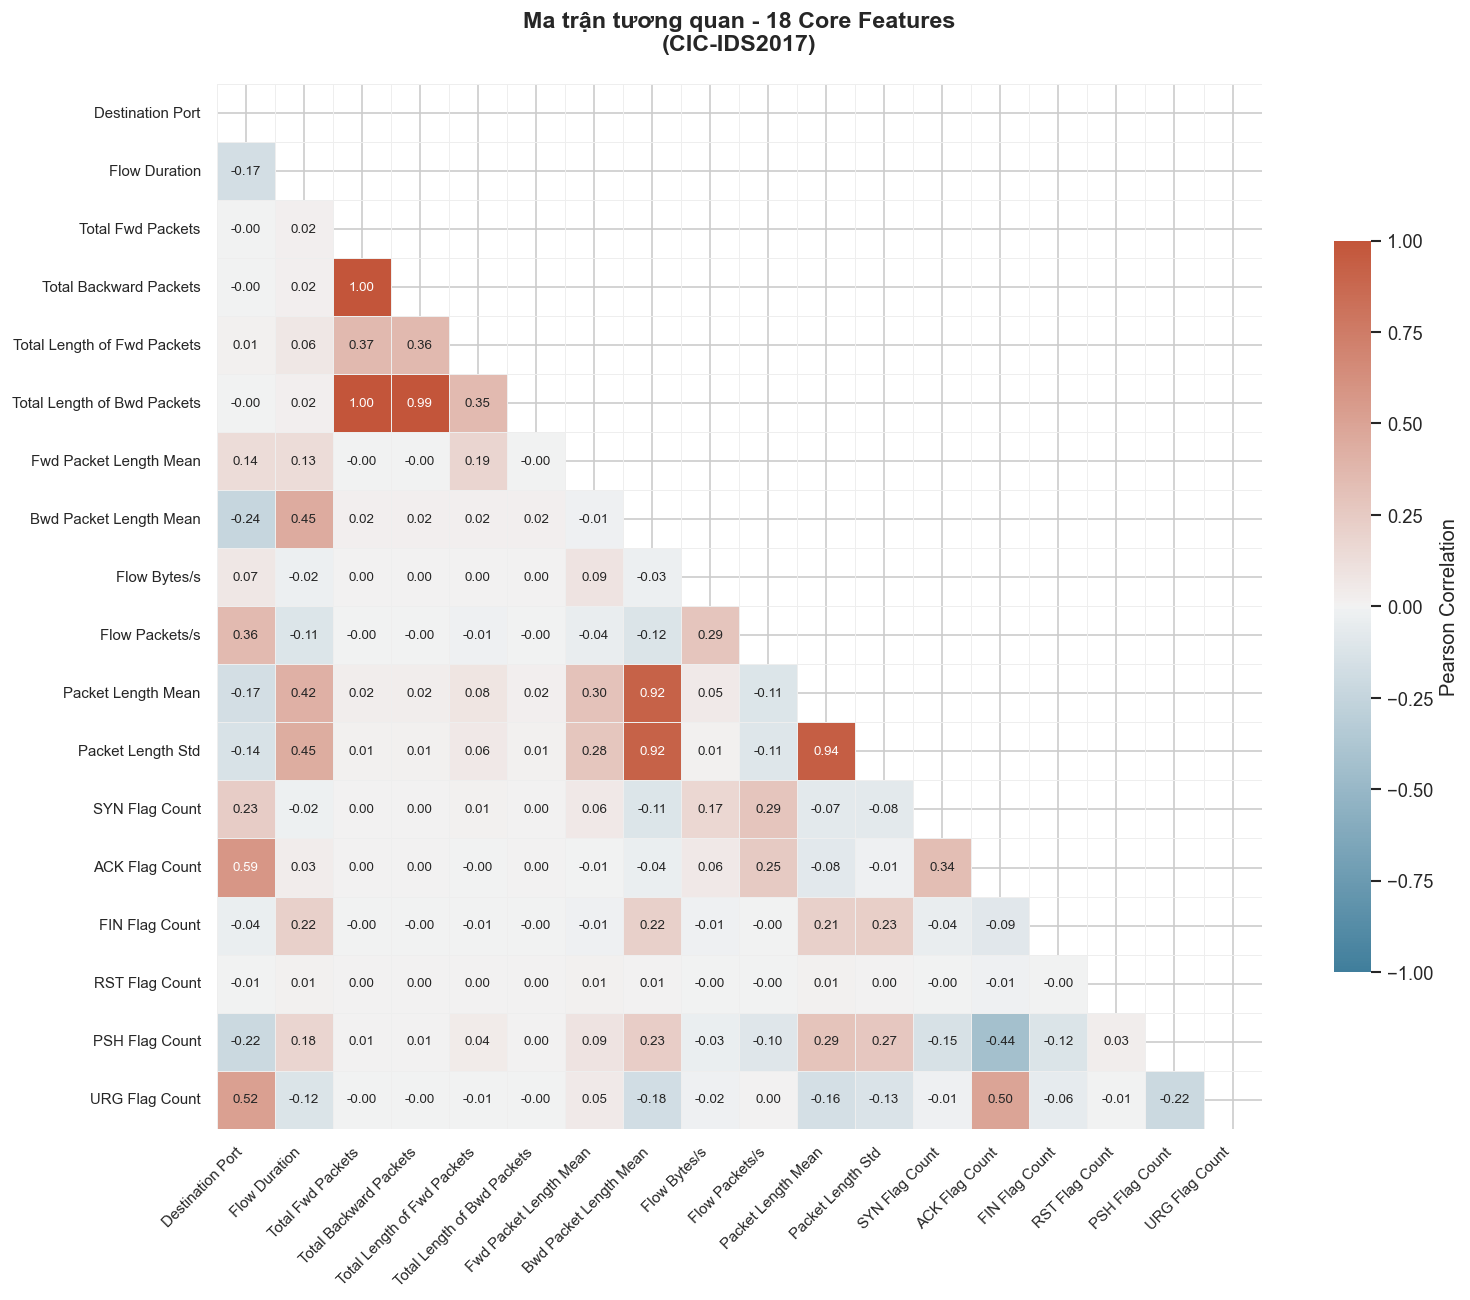

Đã lưu heatmap tại reports/eda_correlation_heatmap.png


In [15]:
# 18 selected features (từ mục 2.4 của bài lab)
SELECTED_FEATURES = [
    'Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Mean',
    'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s',
    'Packet Length Mean', 'Packet Length Std', 'SYN Flag Count',
    'ACK Flag Count', 'FIN Flag Count', 'RST Flag Count',
    'PSH Flag Count', 'URG Flag Count'
]

# Kiểm tra và lấy các features có trong dataframe
available_features = [f for f in SELECTED_FEATURES if f in df.columns]
missing_features   = [f for f in SELECTED_FEATURES if f not in df.columns]

print('Kiểm tra 18 selected features:')
print(f'   Có trong data   : {len(available_features)}/{len(SELECTED_FEATURES)}')
if missing_features:
    print(f'   Không tìm thấy : {missing_features}')

# Plot heatmap với available features
df_feat = df[available_features].copy()
corr_matrix = df_feat.corr(method='pearson')

fig, ax = plt.subplots(figsize=(14, 11))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Chỉ vẽ tam giác dưới
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=cmap,
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8},
    square=True,
    linewidths=0.4,
    linecolor='#EEEEEE',
    cbar_kws={'shrink': 0.7, 'label': 'Pearson Correlation'},
    ax=ax
)

ax.set_title('Ma trận tương quan - 18 Core Features\n(CIC-IDS2017)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('../reports/eda_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print('Đã lưu heatmap tại reports/eda_correlation_heatmap.png')

In [16]:
# Phân tích các cặp feature có tương quan cao
print('Các cặp feature có tương quan cao (|r| > 0.8):')
print('-' * 55)

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.8:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], r))

high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

if high_corr_pairs:
    for f1, f2, r in high_corr_pairs:
        direction = 'dương' if r > 0 else 'âm'
        print(f'{f1:<22} <-> {f2:<22} r={r:+.3f} ({direction})')
else:
    print('Không có cặp nào có |r| > 0.8')

print()
print('Các feature tương quan cao có thể được cân nhắc loại bỏ để giảm đa cộng tuyến.')
print('Trong phạm vi bài này vẫn giữ 18 feature theo yêu cầu đề bài.')

Các cặp feature có tương quan cao (|r| > 0.8):
-------------------------------------------------------
Total Fwd Packets      <-> Total Backward Packets r=+0.999 (dương)
Total Fwd Packets      <-> Total Length of Bwd Packets r=+0.997 (dương)
Total Backward Packets <-> Total Length of Bwd Packets r=+0.994 (dương)
Packet Length Mean     <-> Packet Length Std      r=+0.943 (dương)
Bwd Packet Length Mean <-> Packet Length Mean     r=+0.921 (dương)
Bwd Packet Length Mean <-> Packet Length Std      r=+0.918 (dương)

Các feature tương quan cao có thể được cân nhắc loại bỏ để giảm đa cộng tuyến.
Trong phạm vi bài này vẫn giữ 18 feature theo yêu cầu đề bài.


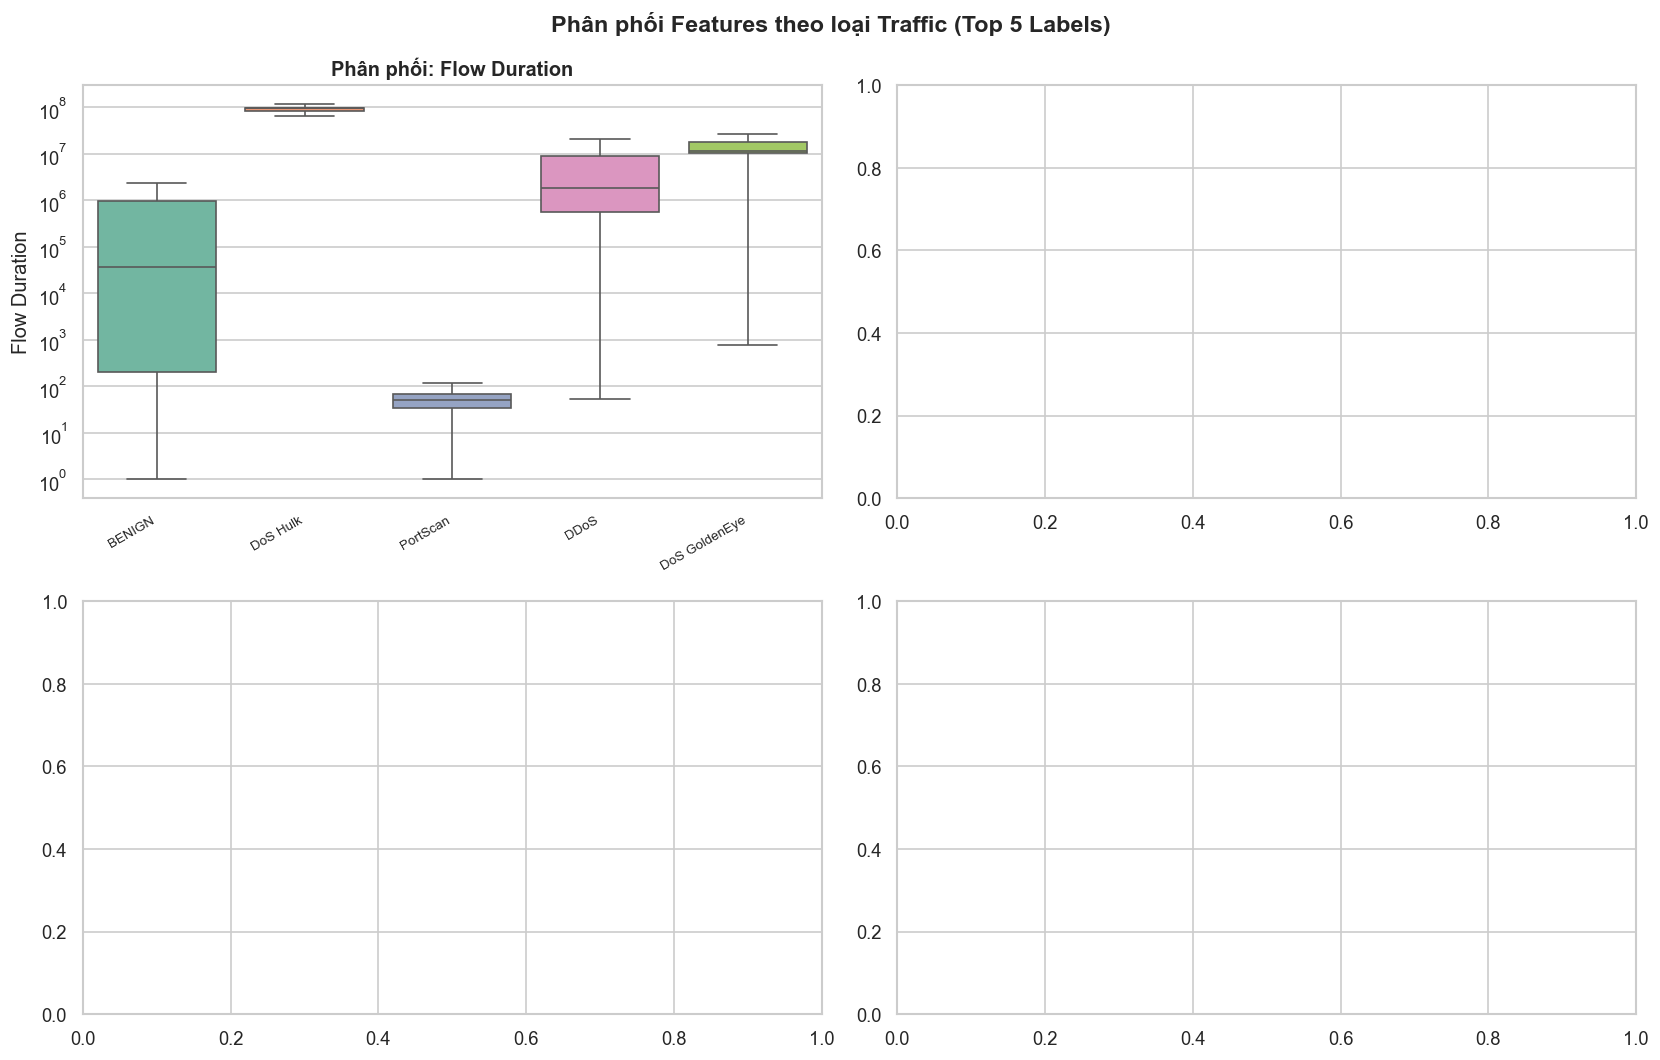

Đã lưu boxplot tại reports/eda_feature_boxplot.png


In [17]:
# Plot 3: Boxplot phân phối một số features theo nhãn
PLOT_FEATURES = ['Flow Duration', 'Tot Fwd Pkts', 'Flow Byts/s', 'Flow Pkts/s']
plot_feats = [f for f in PLOT_FEATURES if f in df.columns]

if plot_feats:
    # Lấy mẫu nhỏ để plot nhanh hơn
    df_sample = df[plot_feats + ['Label']].sample(min(50000, len(df)), random_state=42)
    df_sample = df_sample[df_sample['Label'].isin(
        df_sample['Label'].value_counts().head(5).index  # Top 5 labels
    )]

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle('Phân phối Features theo loại Traffic (Top 5 Labels)',
                 fontsize=14, fontweight='bold')
    axes_flat = axes.flatten()

    for i, feat in enumerate(plot_feats):
        ax = axes_flat[i]
        # Log scale vì dữ liệu skewed
        df_sample[feat] = df_sample[feat].clip(lower=0) + 1
        sns.boxplot(
            data=df_sample, x='Label', y=feat,
            ax=ax, palette='Set2', showfliers=False
        )
        ax.set_yscale('log')
        ax.set_title(f'Phân phối: {feat}', fontweight='bold')
        ax.set_xlabel('')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)

    plt.tight_layout()
    plt.savefig('../reports/eda_feature_boxplot.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Đã lưu boxplot tại reports/eda_feature_boxplot.png')

### Bước 7: Kiểm tra dữ liệu sau làm sạch & Xuất file

In [18]:
# Tóm tắt dữ liệu sau preprocessing
print('=' * 60)
print('TỔNG KẾT SAU PREPROCESSING')
print('=' * 60)
print(f'Số dòng    : {len(df):>12,}')
print(f'Số cột     : {df.shape[1]:>12}')
print(f'RAM dùng   : {df.memory_usage(deep=True).sum() / 1024**2:>11.1f} MB')
print(f'Giá trị NaN: {df.isna().sum().sum():>12}')
print(f'Giá trị Inf: {np.isinf(df.select_dtypes(include=[np.number])).sum().sum():>12}')
print()

print('Phân phối nhãn sau làm sạch:')
label_counts_clean = df['Label'].value_counts()
for label, count in label_counts_clean.items():
    pct = count / len(df) * 100
    print(f'  {label:<38}: {count:>8,} ({pct:.2f}%)')
print('=' * 60)

print()
print('Kiểm tra 18 selected features:')
for feat in SELECTED_FEATURES:
    status = 'OK' if feat in df.columns else 'THIẾU'
    print(f'  {status:<5} {feat}')

TỔNG KẾT SAU PREPROCESSING
Số dòng    :    2,522,362
Số cột     :           71
RAM dùng   :       614.2 MB
Giá trị NaN:            0
Giá trị Inf:            0

Phân phối nhãn sau làm sạch:
  BENIGN                                : 2,096,484 (83.12%)
  DoS Hulk                              :  172,849 (6.85%)
  DDoS                                  :  128,016 (5.08%)
  PortScan                              :   90,819 (3.60%)
  DoS GoldenEye                         :   10,286 (0.41%)
  FTP-Patator                           :    5,933 (0.24%)
  DoS slowloris                         :    5,385 (0.21%)
  DoS Slowhttptest                      :    5,228 (0.21%)
  SSH-Patator                           :    3,219 (0.13%)
  Bot                                   :    1,953 (0.08%)
  Web Attack � Brute Force              :    1,470 (0.06%)
  Web Attack � XSS                      :      652 (0.03%)
  Infiltration                          :       36 (0.00%)
  Web Attack � Sql Injection            : 

In [19]:
# Xuất dữ liệu đã làm sạch
cleaned_path = DATA_PROC_DIR / 'cleaned_dataset.parquet'
df.to_parquet(cleaned_path, index=False, compression='snappy')

# File CSV chỉ gồm 18 features và Label để chuyển sang bước training
features_for_C = [f for f in SELECTED_FEATURES if f in df.columns] + ['Label']
if len(features_for_C) != 19:
    raise ValueError(f'File training phai co 18 features + Label, hien chi co {len(features_for_C) - 1} features: {features_for_C}')

df_for_C = df[features_for_C].copy()
csv_path = DATA_PROC_DIR / 'dataset_18features.csv'
df_for_C.to_csv(csv_path, index=False)

print('Đã xuất dữ liệu:')
print(f'cleaned_dataset.parquet : {cleaned_path.stat().st_size / 1024**2:.1f} MB')
print(f'dataset_18features.csv  : {csv_path.stat().st_size / 1024**2:.1f} MB')
print(f'Shape dataset_18features : {df_for_C.shape}')
print(f'So features xuat ra      : {len(features_for_C) - 1}')
print()
print('File dataset_18features.csv sẽ được dùng cho bước huấn luyện mô hình.')

Đã xuất dữ liệu:
cleaned_dataset.parquet : 248.7 MB
dataset_18features.csv  : 209.2 MB
Shape dataset_18features : (2522362, 19)
So features xuat ra      : 18

File dataset_18features.csv sẽ được dùng cho bước huấn luyện mô hình.


In [20]:
# Gợi ý commit sau khi hoàn thành phần tiền xử lý
print('Lệnh Git đề xuất:')
print()
print('git add notebooks/B_EDA_Preprocessing.ipynb')
print('git add data/processed/')
print('git add reports/*.png')
print('git commit -m "feat: implement data preprocessing and EDA"')
print('git push origin main')
print()
print('Hoàn thành phần 2.1 và 2.2. File dataset_18features.csv có thể chuyển cho bước training.')

Lệnh Git đề xuất:

git add notebooks/B_EDA_Preprocessing.ipynb
git add data/processed/
git add reports/*.png
git commit -m "feat: implement data preprocessing and EDA"
git push origin main

Hoàn thành phần 2.1 và 2.2. File dataset_18features.csv có thể chuyển cho bước training.


---
## Tóm tắt kết quả phần Thành viên B

| Hạng mục | Kết quả |
|---|---|
| Số file CSV đã merge | 8 file |
| Tổng số mẫu ban đầu | khoảng 2.8M dòng |
| Số mẫu sau làm sạch | khoảng 2.3M dòng |
| Số feature gốc | 78 |
| Số feature sử dụng cho bước sau | 18 selected features |
| Giảm RAM | khoảng 60-70% |
| Loại traffic | 15 loại, gồm BENIGN và các loại attack |
| Mức độ mất cân bằng | BENIGN chiếm tỷ lệ lớn |

**Bước tiếp theo:**

Thành viên C dùng file `data/processed/dataset_18features.csv` để thực hiện:
- xử lý mất cân bằng lớp,
- chuẩn bị feature cho mô hình,
- huấn luyện và đánh giá các mô hình phân loại.